# Описание данных

Данные - специально подготовленная выборка из полного набора, описанного здесь: https://mengtingwan.github.io/data/goodreads#datasets с дополнениями из https://www.kaggle.com/datasets/austinreese/goodreads-books:
- books: перечень книг (~44 тыс.) из списка https://www.goodreads.com/list/show/1.Best_Books_Ever (совпадение по book id),
- interactions: взаимодействие пользователей с книгами

Основной массив данных был собран в конце 2017.

# Инициализация

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

Создаём логгер, который удобен для использования в ноутбуке.

# Load Data

Загружаем данные как они есть, начинаем на них смотреть: какие в них есть сущности, атрибуты, распределения.

In [3]:
books = pd.read_parquet("books.parquet")

In [4]:
books.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43312 entries, 3 to 2360448
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   book_id               43312 non-null  int64  
 1   author                43312 non-null  object 
 2   title                 43312 non-null  object 
 3   description           43312 non-null  object 
 4   genre_and_votes       43312 non-null  object 
 5   num_pages             37001 non-null  Int64  
 6   average_rating        43312 non-null  float64
 7   ratings_count         43312 non-null  Int64  
 8   text_reviews_count    43312 non-null  int64  
 9   publisher             43312 non-null  object 
 10  publication_year      35891 non-null  Int64  
 11  country_code          43312 non-null  object 
 12  language_code         43312 non-null  object 
 13  format                43312 non-null  object 
 14  is_ebook              43312 non-null  bool   
 15  isbn                  

Пример данных по книгам

In [5]:
print(books[["book_id", "author", "title", "num_pages", "average_rating"]].sample(5, random_state=52).sort_values("book_id").set_index("book_id").to_string())

                                             author                                            title  num_pages  average_rating
book_id                                                                                                                        
69882                 Heinrich Böll, Patrick Bowles                      Billiards at Half-Past Nine        288            3.93
267533                               Robert Cormier                                         8 Plus 1        173            3.67
820966    Martin Luther, J.I. Packer, O.R. Johnston                          The Bondage of the Will        322            4.17
4532622                               Karen Hancock                                      The Enclave        492            3.82
20444381                             Diana Gabaldon  Os tambores de outono - 1ª Parte (Outlander #4)       1048            3.99


In [6]:
books.head()

,book_id,author,title,description,genre_and_votes,num_pages,average_rating,ratings_count,text_reviews_count,publisher,publication_year,country_code,language_code,format,is_ebook,isbn,isbn13,genre_and_votes_dict,genre_and_votes_str
3,6066819,Jennifer Weiner,Best Friends Forever,Addie Downs and Valerie Adler were eight when ...,"{'Womens Fiction-Chick Lit': 739, 'Fiction': 442}",368,3.49,51184,3282,Atria Books,2009,US,eng,Hardcover,False,0743294297,9780743294294,"{'Academic': None, 'Academic-Academia': None, ...","Womens Fiction-Chick Lit 739, Fiction 442"
6,378460,Michael Halberstam,The Wanting of Levine,,"{'Politics': 1, 'Humor': 1}",<NA>,4.38,12,4,Berkley Publishing Group,1979,US,,Paperback,False,0425040887,9780425040881,"{'Academic': None, 'Academic-Academia': None, ...","Politics 1user, Humor 1user"
15,89375,"Don Piper, Cecil Murphey",90 Minutes in Heaven: A True Story of Death an...,As he is driving home from a minister's confer...,"{'Christian': 395, 'Nonfiction': 392, 'Religio...",<NA>,3.91,68157,2885,,<NA>,US,,,False,0800759494,9780800759490,"{'Academic': None, 'Academic-Academia': None, ...","Christian 395, Nonfiction 392, Religion 142, S..."
16,89376,Randy Alcorn,Heaven,What is Heaven really going to be like? What w...,"{'Christian': 225, 'Religion-Theology': 154, '...",533,4.26,7345,566,,<NA>,US,eng,,False,0842379428,9780842379427,"{'Academic': None, 'Academic-Academia': None, ...","Christian 225, Religion-Theology 154, Nonficti..."
17,89377,Jennifer L. Holm,Penny from Heaven,It's 1953 and 11-year-old Penny dreams of a su...,"{'Historical-Historical Fiction': 284, 'Childr...",288,3.98,6949,615,Random House Books for Young Readers,2006,US,,Hardcover,False,037583687X,9780375836879,"{'Academic': None, 'Academic-Academia': None, ...","Historical-Historical Fiction 284, Childrens-M..."


In [7]:
interactions = pd.read_parquet("interactions.parquet")

Можно оценить объём данных о взаимодействиях

In [8]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12890434 entries, 0 to 12914458
Data columns (total 7 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   user_id      object
 1   book_id      int64 
 2   started_at   object
 3   read_at      object
 4   is_read      bool  
 5   rating       int64 
 6   is_reviewed  bool  
dtypes: bool(2), int64(2), object(3)
memory usage: 614.7+ MB


Пример данных по взаимодействиям

In [9]:
print(interactions[["user_id", "book_id", "started_at", "read_at", "is_read", "rating"]].sample(5, random_state=52).sort_values("user_id").set_index(["user_id", "book_id"]).to_string())

                                           started_at     read_at  is_read  rating
user_id                          book_id                                          
0447747f44c0d8d1a08cf329fe253f29 10054335  2016-04-08  2016-04-20     True       3
14432756ffba6357686f09e4ccc332bb 26252859  2016-05-27  2016-05-30     True       5
46d6c8cf548d1c86abb671f42ba71b5e 960       2014-08-06  2016-10-29     True       5
71c2b3714945af1f700f49953904c510 18492859  2014-10-09  2014-10-12     True       5
7802bafdeac8abff23a72b9dd60b1dd1 18710190  2015-03-01  2015-05-05     True       4


# EDA

Посмотрим на данные о книгах, какие поля есть.

In [10]:
books.sample(3).T

,2319712,17558,1851101
book_id,429024,22201,9938498
author,"Charles Dickens, Norman Page",Karen Traviss,Erik Larson
title,The Old Curiosity Shop,"Triple Zero (Star Wars: Republic Commando, #2)","In the Garden of Beasts: Love, Terror, and an ..."
description,"The archetypal Victorian melodrama, as heartfe...",,"The time is 1933, the place, Berlin, when Will..."
genre_and_votes,"{'Classics': 1317, 'Fiction': 508, 'Literature...","{'Media Tie In-Star Wars': 764, 'Science Ficti...","{'History': 3735, 'Nonfiction': 3681, 'War-Wor..."
num_pages,576,393,448
average_rating,3.75,4.22,3.81
ratings_count,11395,4408,112419
text_reviews_count,577,134,11669
publisher,Penguin Classics,,Crown


Посмотрим на данные о взаимодействиях пользователей с книгами.

In [11]:
books["book_id"].nunique()

43312

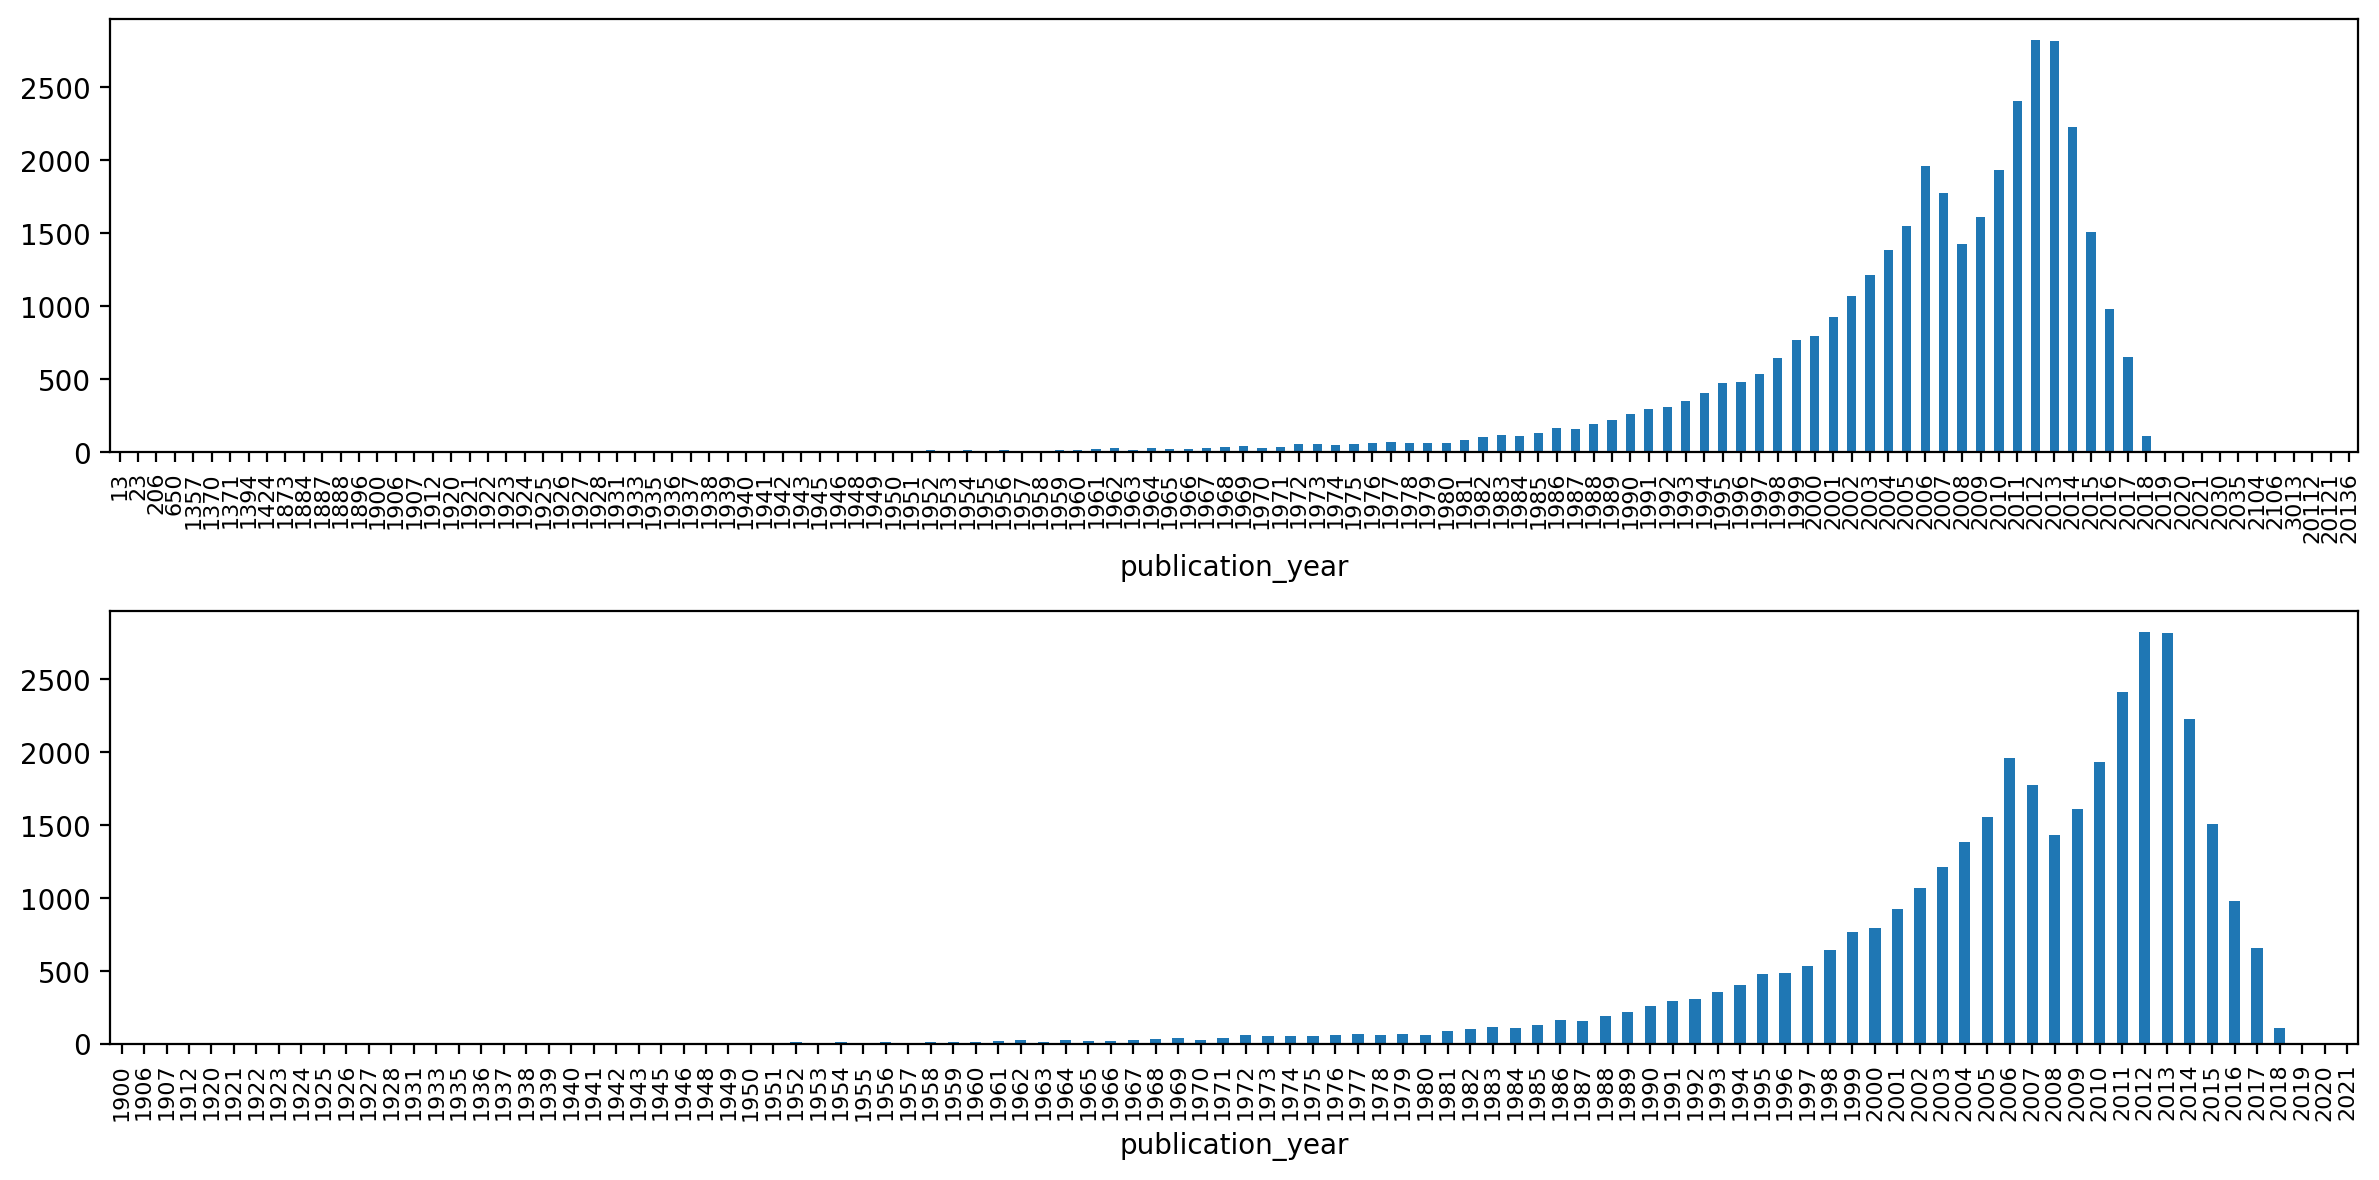

In [12]:
# распределение книг по годам публикации

fig, axs = plt.subplots(2, 1, figsize=(12, 6))

ax = axs[0]
books["publication_year"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.tick_params(axis='x', labelsize=8)

ax = axs[1]
books.query("publication_year >= 1900 and publication_year <= 2025")["publication_year"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.tick_params(axis='x', labelsize=8)

fig.tight_layout()

# События по месяцам

In [13]:
from pandas.tseries.offsets import MonthEnd

interactions["started_at_month"] = pd.to_datetime(interactions["started_at"]).dt.to_period('M').dt.to_timestamp().dt.date

In [14]:
interactions_by_month = interactions.groupby("started_at_month").agg(events=("started_at", "count"), users=("user_id", "nunique")).reset_index()

In [15]:
interactions_by_month

,started_at_month,events,users
0,2007-01-01,1993,1071
1,2007-02-01,201,135
2,2007-03-01,222,152
3,2007-04-01,201,135
4,2007-05-01,204,138
...,...,...,...
127,2017-08-01,202129,93040
128,2017-09-01,172187,82694
129,2017-10-01,108107,58076
130,2017-11-01,565,475


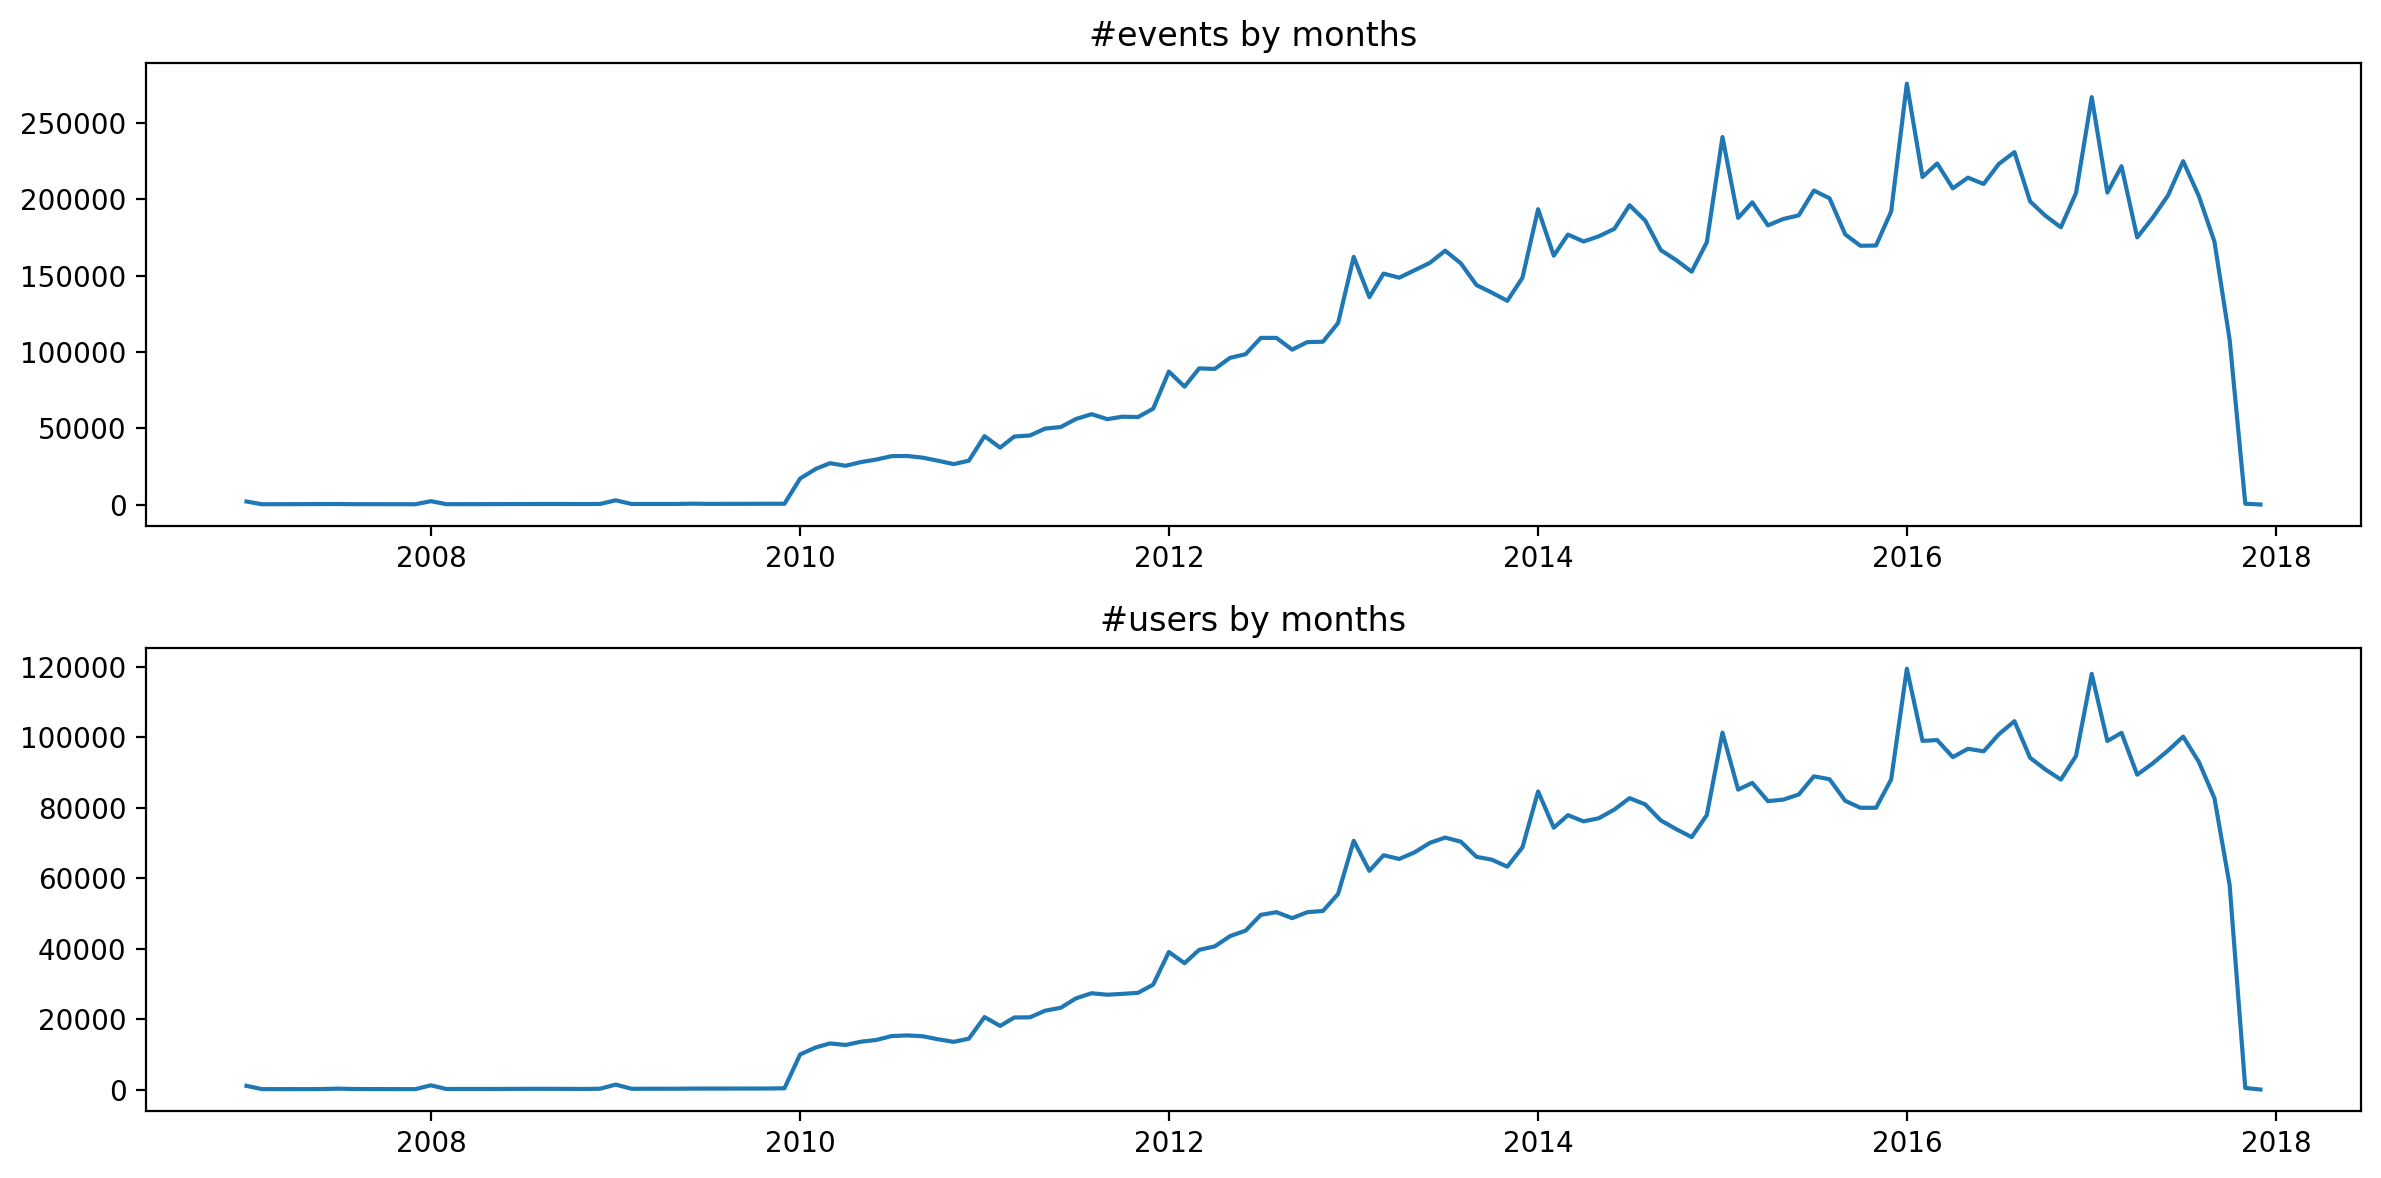

In [16]:
# распределение взаимодействий по годам

fig, axs = plt.subplots(2, 1, figsize=(12, 6))

ax = axs[0]
ax.plot(interactions_by_month["started_at_month"], interactions_by_month["events"])
# ax.tick_params(axis='x', labelsize=8)
ax.set_title("#events by months")

ax = axs[1]
ax.plot(interactions_by_month["started_at_month"], interactions_by_month["users"])
# ax.tick_params(axis='x', labelsize=8)
ax.set_title("#users by months")

fig.tight_layout()

In [17]:
# кол-во пользователей
interactions["user_id"].nunique()

542657

In [18]:
# среднее количество прочитанных книг на пользователя
len(interactions) / interactions["user_id"].nunique()

23.7542941489744

In [19]:
# кол-во книг без рейтинга
len(books[books["ratings_count"] == 0])

9

<Axes: xlabel='average_rating'>

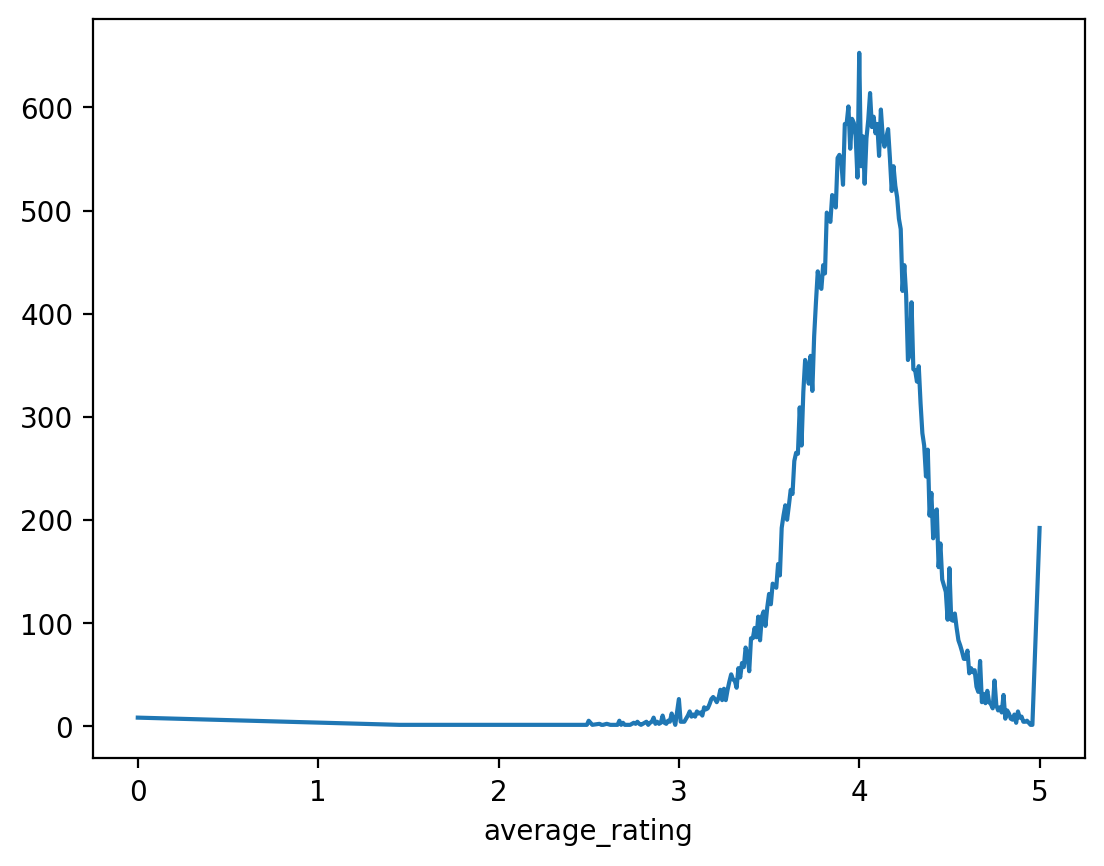

In [ ]:
# распределение среднего рейтинга
books["average_rating"].value_counts().sort_index().plot(kind="line")

<Axes: xlabel='ratings_count'>

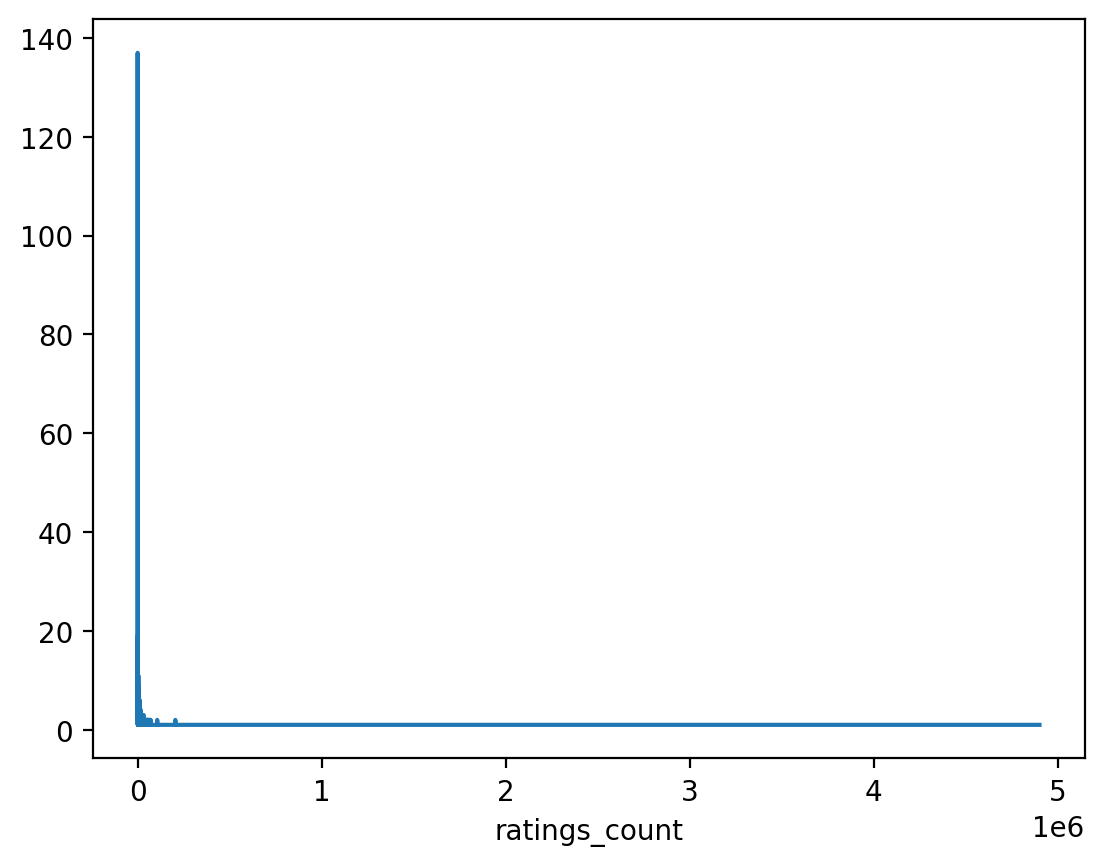

In [ ]:
# распределение количества рейтингов
books["ratings_count"].value_counts().sort_index().plot(kind="line")

<Axes: xlabel='user_id'>

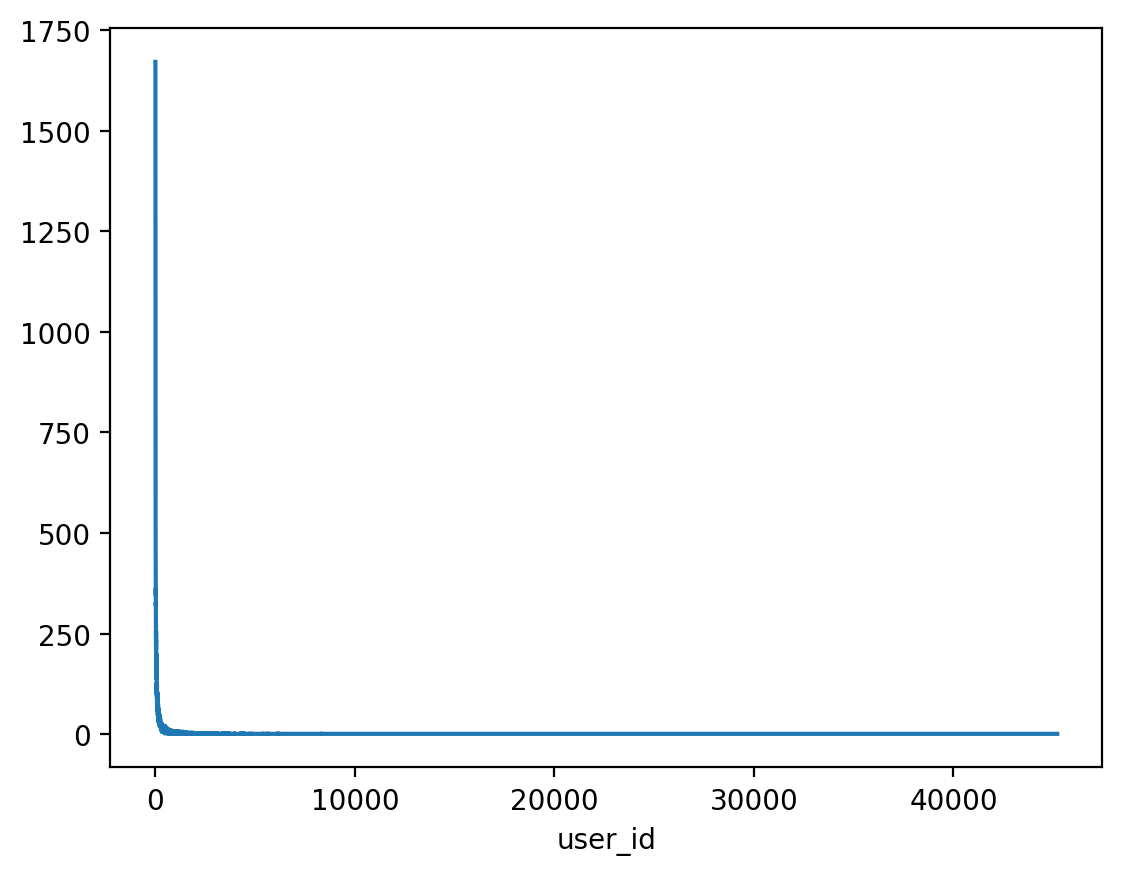

In [27]:
interactions.groupby(by="book_id")["user_id"].count().value_counts().sort_index().plot(kind="line")

In [28]:
books.columns

Index(['book_id', 'author', 'title', 'description', 'genre_and_votes',
       'num_pages', 'average_rating', 'ratings_count', 'text_reviews_count',
       'publisher', 'publication_year', 'country_code', 'language_code',
       'format', 'is_ebook', 'isbn', 'isbn13', 'genre_and_votes_dict',
       'genre_and_votes_str'],
      dtype='object')

In [ ]:
# Проверим, что все ид книг уникальные
books["book_id"].nunique() == len(books)

True

In [ ]:
# проверим и заполним пропуски в кол-ве страниц
len(books[books["num_pages"].isna()])

6311

In [38]:
books.loc[books["num_pages"].isna(), "num_pages"] = int(books["num_pages"].mean())

In [46]:
# проверим и заполним пропуски в годе выпуска
len(books[books["publication_year"].isna()])

7421

In [49]:
books.loc[books["publication_year"].isna(), "publication_year"] = int(books["publication_year"].median())

In [ ]:
# проверим странные годы
books["publication_year"].unique()[books["publication_year"].unique() < 1800]

<IntegerArray>
[1371, 1357, 206, 1394, 23, 650, 1424, 13, 1370]
Length: 9, dtype: Int64

In [63]:
books[books["publication_year"] == 206]

,book_id,author,title,description,genre_and_votes,num_pages,average_rating,ratings_count,text_reviews_count,publisher,publication_year,country_code,language_code,format,is_ebook,isbn,isbn13,genre_and_votes_dict,genre_and_votes_str
837067,2858266,"Robin Walker, Fari Supiya",When We Ruled: The Ancient and Medieval Histor...,When We Ruledis by far the best general work o...,"{'History': 28, 'Nonfiction': 18, 'Cultural-Af...",713,4.38,99,7,Every Generation Media,206,US,en-GB,Hardcover,False,095510680X,9780955106804,"{'Academic': None, 'Academic-Academia': None, ...","History 28, Nonfiction 18, Cultural-Africa 14,..."


In [65]:
books[books["publication_year"] == 23]

,book_id,author,title,description,genre_and_votes,num_pages,average_rating,ratings_count,text_reviews_count,publisher,publication_year,country_code,language_code,format,is_ebook,isbn,isbn13,genre_and_votes_dict,genre_and_votes_str
1637948,6557009,Richard C. Woolfson,بماذا يفكر طفلي؟,mt~ ybd' l'Tfl lrD` blt`rf l~ mn`ksthm lkhS@? ...,None,144,4.08,46,4,'kdymy ntrnshwnl,23,US,ara,,False,,,None,None


In [68]:
books[books["publication_year"] == 13]

,book_id,author,title,description,genre_and_votes,num_pages,average_rating,ratings_count,text_reviews_count,publisher,publication_year,country_code,language_code,format,is_ebook,isbn,isbn13,genre_and_votes_dict,genre_and_votes_str
2155231,18620040,Nora Roberts,Catching Snowflakes: Local Hero / A Will and a...,Contains Local Heroand A Will and a Way.,"{'Romance': 20, 'Fiction': 11, 'Holiday-Christ...",512,3.88,125,7,Mills & Boon,13,US,eng,Paperback,False,0263910474,9780263910476,"{'Academic': None, 'Academic-Academia': None, ...","Romance 20, Fiction 11, Holiday-Christmas 10, ..."


In [70]:
books["publication_year"].unique()[books["publication_year"].unique() > 2026]

<IntegerArray>
[20121, 2030, 20136, 2104, 20112, 2106, 2035, 3013]
Length: 8, dtype: Int64

In [74]:
books['publication_year'] = books['publication_year'].replace({206: 2006, 23: 2003, 13: 2013, 20121: 2012, 2030: 2003, 20136: 2013, 2104: 2014, 20112: 2012, 2106: 2016, 2035: 2005, 3013: 2013})

In [ ]:
# проверим и заполним пропуски в языковом коде
len(books.loc[books['language_code'] == ""])

10674

In [ ]:
books.loc[books['language_code'] == "", 'language_code'] = books['language_code'].value_counts().index[0]

In [87]:
# проверим и заполним пропуски в формате
len(books.loc[books['format'] == ""])

8407

In [88]:
books.loc[books['format'] == "", 'format'] = books['format'].value_counts().index[0]

In [92]:
interactions.columns

Index(['user_id', 'book_id', 'started_at', 'read_at', 'is_read', 'rating',
       'is_reviewed', 'started_at_month'],
      dtype='object')

# Преобработка

Примем новые именования:
- books -> items (более обобщённое название)
- interactions -> events (несколько короче, удобнее в коде)

In [105]:
items = books.copy()
events = interactions.copy()

In [17]:
del books
del interactions

In [106]:
# оставим события только до ноября 2017

event_cutoff_date = pd.to_datetime("2017-11-01").date()
events = events.query("started_at < @event_cutoff_date and read_at < @event_cutoff_date").copy()

In [ ]:
# Удалим события без рейтинга
events = events[events["rating"] > 0]

In [ ]:
# уже есть только прочитанные
events["is_read"].value_counts(dropna=False)

is_read
True    11836282
Name: count, dtype: int64

In [118]:
# оставим только пользователей, прочитавших 2 и более книг
events = events[events["user_id"].isin(events["user_id"].value_counts()[events["user_id"].value_counts() >= 2].index)]

In [120]:
events = events.rename(columns={"book_id": "item_id"})

In [121]:
items = items.rename(columns={"book_id": "item_id"})

In [ ]:
# изменим юзер ид
new_idx = events["user_id"].drop_duplicates().sort_values().reset_index(drop=True)
new_idx

0         00000377eea48021d3002730d56aca9a
1         00004584d524ec468619e81b176cc991
2         000079c580bbe45e1500acabe551b276
3         00009e46d18f223a82b22da38586b605
4         0000c3d51aa099745e93a4e99c4856c8
                        ...               
430580    ffff7cf38c717c8172ff5ba656cec6df
430581    ffffbb062a8b208c9c1031b529c08f7a
430582    ffffd81a724c0fa70ac37cd347c1c0f1
430583    ffffe38c3a89ad5122e17e4cb9997fe4
430584    fffff8a718843c0e11dfd93fb41c1297
Name: user_id, Length: 430585, dtype: object

In [135]:
new_idx.index = new_idx.index + 1000000
new_idx

1000000    00000377eea48021d3002730d56aca9a
1000001    00004584d524ec468619e81b176cc991
1000002    000079c580bbe45e1500acabe551b276
1000003    00009e46d18f223a82b22da38586b605
1000004    0000c3d51aa099745e93a4e99c4856c8
                         ...               
1430580    ffff7cf38c717c8172ff5ba656cec6df
1430581    ffffbb062a8b208c9c1031b529c08f7a
1430582    ffffd81a724c0fa70ac37cd347c1c0f1
1430583    ffffe38c3a89ad5122e17e4cb9997fe4
1430584    fffff8a718843c0e11dfd93fb41c1297
Name: user_id, Length: 430585, dtype: object

In [141]:
new_idx = new_idx.reset_index().set_index("user_id").squeeze()
new_idx

user_id
00000377eea48021d3002730d56aca9a    1000000
00004584d524ec468619e81b176cc991    1000001
000079c580bbe45e1500acabe551b276    1000002
00009e46d18f223a82b22da38586b605    1000003
0000c3d51aa099745e93a4e99c4856c8    1000004
                                     ...   
ffff7cf38c717c8172ff5ba656cec6df    1430580
ffffbb062a8b208c9c1031b529c08f7a    1430581
ffffd81a724c0fa70ac37cd347c1c0f1    1430582
ffffe38c3a89ad5122e17e4cb9997fe4    1430583
fffff8a718843c0e11dfd93fb41c1297    1430584
Name: index, Length: 430585, dtype: int64

In [142]:
new_idx.loc["8f50136afeb65c55cec7b3d306c24b03"]

1241243

In [143]:
events["user_id"] = events["user_id"].map(new_idx)

In [124]:
len(events) / len(interactions)

0.9116129061286843

# Сохранение результатов

In [125]:
items.to_parquet("items.parquet")

In [144]:
events.to_parquet("events.parquet")